In [1]:
%pip install numpy pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


X_train shape: (1005, 20)
X_test shape: (335, 20)
y_train shape: (1005,)
y_test shape: (335,)
Accuracy : 0.6478
Precision: 0.8358
Recall   : 0.5385
F1 Score : 0.6550


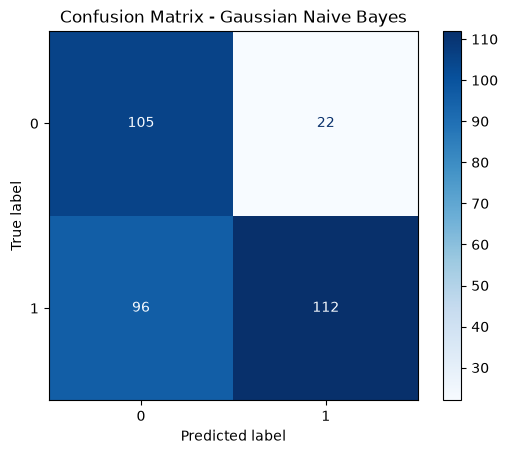

In [9]:
import numpy as np
import pandas as pd
from sklearn import naive_bayes, model_selection, metrics

bt_4 = pd.read_csv('bt2.csv')
bt_4.head()

y = bt_4['target_5yrs']
X = bt_4.drop(columns=['target_5yrs']).select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.25, random_state=42
)

nb = naive_bayes.GaussianNB()

# Fit the model on your training data.
nb.fit(X_train, y_train)

# Apply your model to predict on your test data.
y_pred = nb.predict(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# 1. Tính toán các chỉ số phân loại
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# 2. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
import matplotlib.pyplot as plt

cm = metrics.confusion_matrix(y_test, y_pred, labels=nb.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()